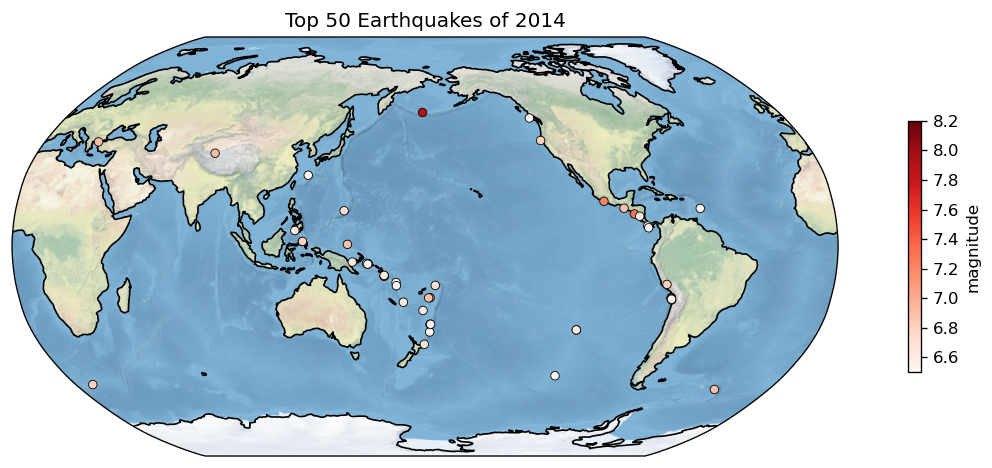

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1. 读入数据
eq = pd.read_csv("C:\\Users\\Libing\\Desktop\\usgs_earthquakes.csv",
                 parse_dates=['time', 'updated'],
                 index_col='id')

# 2. 选出震级最大的 50 次地震
top50 = eq.nlargest(50, 'mag')

# 3. 画图：Robinson 投影，中心经度 180°
plt.figure(figsize=(12, 4), dpi=120)
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.stock_img()          # 背景地球图
ax.coastlines()         # 海岸线

# 散点；颜色代表震级
sc = ax.scatter(top50['longitude'],
                top50['latitude'],
                c=top50['mag'],
                s=26, #点的大小
                zorder=2,
                transform=ccrs.PlateCarree(),
                cmap='Reds',
                edgecolors='k',
                linewidths=0.5)  

# 颜色条
cbar = plt.colorbar(sc, ax=ax,orientation='vertical',label='magnitude',shrink=0.6,
                    ticks=[6.6,6.8,7.0,7.2,7.4,7.6,7.8,8.0,8.2])

ax.set_title('Top 50 Earthquakes of 2014')
plt.tight_layout()
plt.show()

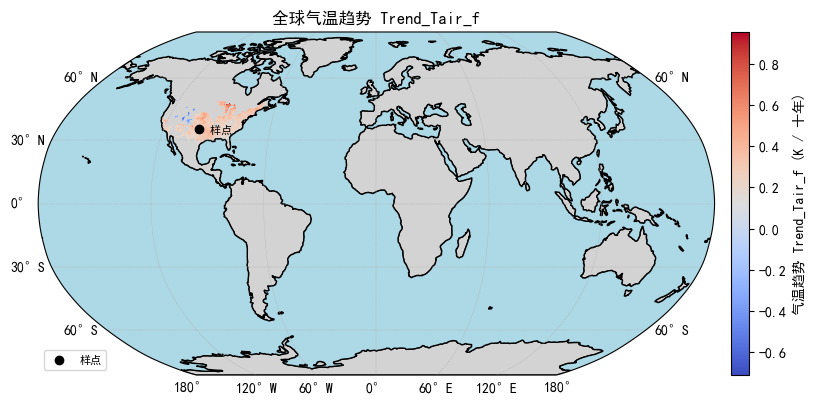

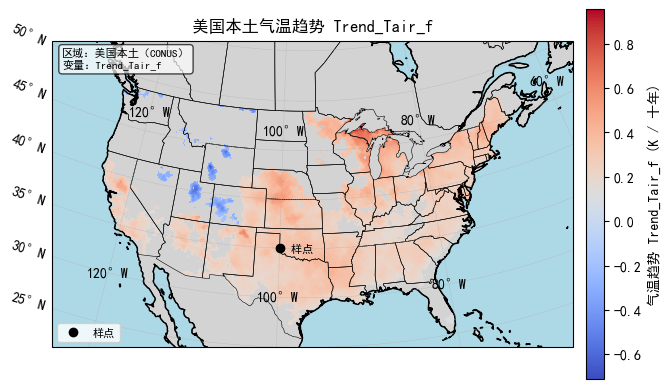

In [35]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 中文字体设置，防止中文乱码和负号变方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
ds  = xr.open_dataset(r"C:\Users\Libing\Desktop\NCALDAS_NOAH0125_Trends.A198010_201509.002.nc")
da  = ds["Trend_Tair_f"].squeeze() #提取所需数据
lon = ds["lon"]
lat = ds["lat"]

# 样点位置
lon0, lat0 = -100, 35

# 2.1 全局图
fig, ax = plt.subplots(figsize=(9, 4),subplot_kw={"projection": ccrs.Robinson()}) # 投影为 Robinson
ax.set_global() #显示全局地图

# 绘制地理特征：陆地、海洋、海岸线
ax.add_feature(cfeature.LAND,  edgecolor="k", facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.coastlines()

# 添加网格线和经纬度标签
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.3)
gl.top_labels = False #取消顶部的经度标签
gl.right_labels = False #取消右侧的维度标签

# 填色图（变量） + 颜色条
im = ax.pcolormesh(lon, lat, da,transform=ccrs.PlateCarree(),cmap="coolwarm")
plt.colorbar(im, ax=ax, pad=0.02,label="气温趋势 Trend_Tair_f (K / 十年)")

# 标注样点 
ax.plot(lon0, lat0, "ko",transform=ccrs.PlateCarree(),label="样点")  # 作为 legend 的条目
ax.text(lon0, lat0, "  样点",transform=ccrs.PlateCarree(),ha="left", va="center", fontsize=8)

# 图例
ax.legend(loc="lower left", fontsize=8)

# 添加坐标轴标签 + 标题
ax.set_xlabel("经度")
ax.set_ylabel("纬度")
ax.set_title("全球气温趋势 Trend_Tair_f")

#显示图形
plt.tight_layout()
plt.show()

# 2.2 区域图（这里以美国本土作为例子）
fig, ax = plt.subplots(figsize=(7, 4),
    subplot_kw={"projection": ccrs.LambertConformal(  # 另一种投影方法：Lambert Conformal
        central_longitude=-97, central_latitude=35)})

# 区域范围：CONUS（美国本土）
ax.set_extent([-125, -67, 25, 53], crs=ccrs.PlateCarree())

# 绘制地理特征：陆地、海洋、州界、海岸线
ax.add_feature(cfeature.LAND,  edgecolor="k", facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.coastlines()

# 添加网格线和经纬度标签
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.3)
gl.top_labels = False
gl.right_labels = False

# 区域填色图 + 颜色条
im = ax.pcolormesh(lon, lat, da,transform=ccrs.PlateCarree(),cmap="coolwarm")
plt.colorbar(im, ax=ax, pad=0.02,label="气温趋势 Trend_Tair_f (K / 十年)")

# 样点 + 注释
ax.plot(lon0, lat0, "ko",transform=ccrs.PlateCarree(),label="样点")
ax.text(lon0, lat0, "  样点",transform=ccrs.PlateCarree(),ha="left", va="center", fontsize=8)
ax.legend(loc="lower left", fontsize=8)

# 文本框（text box）
ax.text(
    0.02, 0.98,"区域：美国本土（CONUS）\n变量：Trend_Tair_f",
    transform=ax.transAxes,ha="left", va="top", fontsize=8,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# 坐标轴标签 + 标题
ax.set_xlabel("经度")
ax.set_ylabel("纬度")
ax.set_title("美国本土气温趋势 Trend_Tair_f")

plt.tight_layout()
plt.show()